In [1]:
from matplotlib import colors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
import math
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import json
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

In [2]:
path_optical = 'C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC 6218/optical_data.txt'
path_arrival_optical = 'C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC6809_optical.csv'
Mag_min = -50
Mag_max = 50
RMS_max = 1
Fit_max = 1.5
Sharp_min = -2
Sharp_max = 2
CM_min = 80
bins_division = 20
min_count = 2
min_step = 2
bluer_limit = 0.5
significantly_bluer_limit = 1.0
redder_limit = 0.5
significantly_redder_limit = 1.0
BS_RA = 295.0357771-295.0358042
BS_Decl = -30.9811814+30.9811333
distance_parsecs = 5400

In [3]:
optical_data = pd.read_csv(
    path_optical,
    sep=r"\s+",      # split by any amount of whitespace
    header=None      # because there are no column names
)
optical_data.columns = [
        "X", "Y",
        "275_Mag", "275_RMS", "275_Fit", "275_Sharp", "275_exp_found", "275_exp_well",
        "336_Mag", "336_RMS", "336_Fit", "336_Sharp", "336_exp_found", "336_exp_well",
        "438_Mag", "438_RMS", "438_Fit", "438_Sharp", "438_exp_found", "438_exp_well",
        "606_Mag", "606_RMS", "606_Fit", "606_Sharp", "606_exp_found", "606_exp_well",
        "814_Mag", "814_RMS", "814_Fit", "814_Sharp", "814_exp_found", "814_exp_well",
        "Cluster_Membership",
        "RA", "Decl",
        "Id",
        "Iteration_found"
]


optical_data["Visible"] = (optical_data["438_Mag"]+optical_data["606_Mag"])/2

optical_data["Mv"] = optical_data["Visible"]-5*(math.log(distance_parsecs/10,10))

bands = ["275", "336", "438", "606", "814"]
mask = np.ones(len(optical_data), dtype=bool)
for b in bands:
    mask &= optical_data[f"{b}_Mag"].between(Mag_min, Mag_max)
    mask &= optical_data[f"{b}_RMS"] < RMS_max
    mask &= optical_data[f"{b}_Fit"] < Fit_max
    mask &= optical_data[f"{b}_Sharp"].between(Sharp_min, Sharp_max)
    mask &= optical_data["Cluster_Membership"] > CM_min


optical_data_filtered = optical_data[mask].copy()
optical_data_filtered.reset_index(inplace = True)
column_drop = ["X", "Y", "Iteration_found", "index"]
for band in bands:
    column_drop.append(band+"_RMS")
    column_drop.append(band+"_Fit")
    column_drop.append(band+"_Sharp")
    column_drop.append(band+"_exp_found")
    column_drop.append(band+"_exp_well")
optical_data_filtered.drop(columns = column_drop, inplace = True)
optical_data_filtered.sort_index(inplace = True)


pairs = [("275", "336"), ("438", "606"), ("606", "814")]


In [4]:
optical_data_filtered

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv
0,18.4296,16.6066,16.2137,14.9318,14.0365,96.9,251.810171,-1.977302,R0000023,15.57275,1.910781
1,19.5118,18.5891,18.7940,17.9390,17.2565,95.7,251.811449,-1.976983,R0000025,18.36650,4.704531
2,19.6241,18.7055,18.8464,18.0989,17.4065,98.1,251.803570,-1.976703,R0000033,18.47265,4.810681
3,19.5652,18.7367,18.8867,18.1112,17.4266,95.7,251.804720,-1.976048,R0000048,18.49895,4.836981
4,20.1092,19.1201,19.4109,18.5125,17.8303,97.7,251.802203,-1.975687,R0000053,18.96170,5.299731
...,...,...,...,...,...,...,...,...,...,...,...
7329,22.3410,21.0745,21.0091,19.8831,19.1218,97.3,251.812864,-1.947712,R0020739,20.44610,6.784131
7330,24.2980,21.8721,21.7242,20.4689,19.6136,97.1,251.812822,-1.947309,R0020740,21.09655,7.434581
7331,25.1194,22.4235,21.9546,20.6912,19.7691,97.6,251.812749,-1.947485,R0020741,21.32290,7.660931
7332,22.2298,20.8946,20.9425,19.8424,19.0744,94.1,251.812475,-1.947544,R0020742,20.39245,6.730481


In [6]:
pair = 1
Color1, Color2 = pairs[pair]
optical_data_filtered[f"{Color1} - {Color2}"] = optical_data_filtered[f"{Color1}_Mag"] - optical_data_filtered[f"{Color2}_Mag"]
S_Color1 = optical_data_filtered[Color1+"_Mag"]
S_Color2 = optical_data_filtered[Color2+"_Mag"]
S_dif = optical_data_filtered[f"{Color1} - {Color2}"]
n_Data = len(S_Color1)
xmax = round(S_dif.max()+1)
xmin = round(S_dif.min()-1)
ymax = round(S_Color2.max()+1)
ymin = round(S_Color2.min()-1)
bins_xy = [bins_division*(xmax-xmin), bins_division*(ymax-ymin)]
range_xy = [[xmin, xmax], [ymin, ymax]]
counts, xedges, yedges = np.histogram2d(S_dif, S_Color2, bins = bins_xy, range = range_xy)
#H = H.T
#H

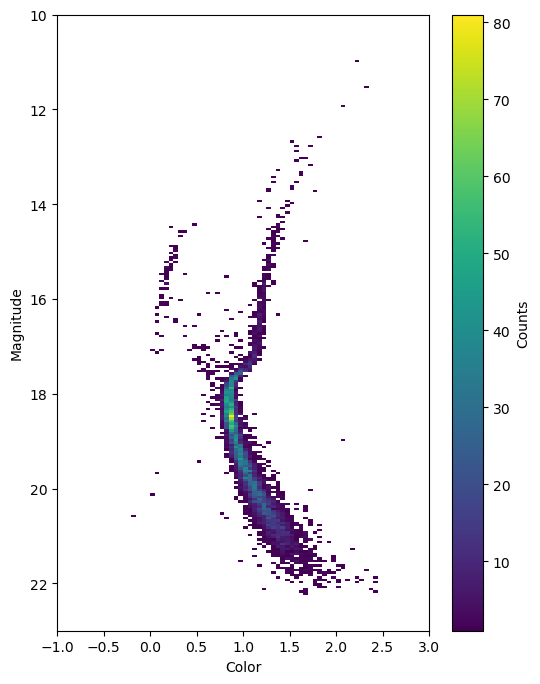

In [7]:
# Mask zero values
counts_masked = np.ma.masked_where(counts == 0, counts)

# Copy viridis colormap
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white')  # masked values → white

# Plot
plt.figure(figsize=(6,8))
plt.pcolormesh(xedges, yedges, counts_masked.T, cmap=cmap)

plt.colorbar(label='Counts')
plt.xlabel('Color')
plt.ylabel('Magnitude')
plt.gca().invert_yaxis()  # important for CMD
plt.show()

In [2]:
def creating_optical_csv(path_optical, path_arrival_optical, Mag_min, Mag_max, RMS_max, Fit_max, Sharp_min, Sharp_max, CM_min,
                         bins_division, min_count, min_step,
                         bluer_limit = 0.5, significantly_bluer_limit = 1.0, redder_limit = 0.5, significantly_redder_limit = 1.0):
    

    for pair in range(3):
        Color1, Color2 = pairs[pair]
        optical_data_filtered[f"{Color1} - {Color2}"] = optical_data_filtered[f"{Color1}_Mag"] - optical_data_filtered[f"{Color2}_Mag"]
        S_Color1 = optical_data_filtered[Color1+"_Mag"]
        S_Color2 = optical_data_filtered[Color2+"_Mag"]
        S_dif = optical_data_filtered[f"{Color1} - {Color2}"]
        n_Data = len(S_Color1)

        xmax = round(S_dif.max()+1)
        xmin = round(S_dif.min()-1)
        ymax = round(S_Color2.max()+1)
        ymin = round(S_Color2.min()-1)

        bins_xy = [bins_division*(xmax-xmin), bins_division*(ymax-ymin)]
        range_xy = [[xmin, xmax], [ymin, ymax]]

        H, x_edges, y_edges = np.histogram2d(S_dif, S_Color2, bins = bins_xy, range = range_xy)

        for i in range(len(H)):
            for j in range(len(H[0])):
                if H[i][j] < min_count:
                    H[i][j] = 0

        x = []
        min = []
        max = []
        for i in H.T:
            #First we go for every bin to find the position of the bins with stars, and we save the count of consecutive 
            # bins with stars (ou) and the count of consecutive bins without stars (n).
            l = []
            k = []
            ll = []
            kk = []
            ku = []
            kkuu = []
            ou = 0
            o = 0
            oo = 0
            n = 0
            c = 0
            for j,z in enumerate(i):
                #We consider that a bin has stars if its count is greater than 0, and we save the position and count of the 
                # bins with stars in k and kk, and we save the position and count of the last consecutive bins with stars in 
                # ku and kkuu.
                if z > 0:
                    n = 0
                    c = 0
                    o += 1
                    k.append(j)     #position
                    kk.append(z)    #value
                    ku = []
                    kkuu = []
                    ou = 0
                else:
                    n += 1
                    c += 2
                    if n < 2:
                        ku = k
                        kkuu = kk
                        ou = o
                        o += 1
                        k.append(j)     #position
                        kk.append(z)    #value
                    else:
                        if ou > oo and ou >= min_step:
                            ll = kkuu
                            l = ku
                            oo = ou
                        kk = []
                        k = []
                        o = 0
                        ku = []
                        kkuu = []
                        ou = 0
            #We save the position of the left and right limits of the main sequence. If there are no stars in any bin, 
            # we save 0 as the limits.
            if len(l)>0:
                min.append(l[0])
                max.append(l[-1])
            else:
                min.append(0)
                max.append(0)
            total = 0
            #We also save the mean position of the bins with stars to plot the mean line of the main sequence.
            if len(l) > 0:
                for j in range(len(l)):
                    total += l[j]*ll[j]
                x.append(total/sum(ll))
            else:
                x.append(0)


        container = []
        chain_width = 0
        maximum = 0
        for i,j in enumerate(x):
            if j == 0:
                container.append(i)
        for i in range(len(container)-1):
            m = container[i+1]-container[i]-1
            if m > maximum:
                maximum = m
                chain_width = container[i]
        main_sequence = range(chain_width+1,chain_width+maximum)
        #Extract the positions (in cells) of the mean, max and min of the main sequence to plot them later. 
        filtered_x = [x[i] for i in main_sequence]
        filtered_max = [max[i] for i in main_sequence]
        filtered_min = [min[i] for i in main_sequence]
        #We obtain the position of the start of the main sequence turn off.
        derivative_x = []
        for i in range(len(x)-1):
            derivative_x.append(x[i]-x[i+1])
        container_d = []
        chain_width_d = 0
        maximum_d = 0
        for i,j in enumerate(derivative_x):
            if j <= 0:
                container_d.append(i)
        for i in range(len(container_d)-1):
            m_d = container_d[i+1]-container_d[i]-1
            if m_d > maximum_d:
                maximum_d = m_d
                chain_width_d = container_d[i]
        msto_start = chain_width_d+maximum_d
        #Change the positions from cells to magnitude values of the CMD
        normalized_min = (np.array(filtered_min)/bins_division)+xmin+1/(2*bins_division)
        normalized_max = (np.array(filtered_max)/bins_division)+xmin-1/(2*bins_division)
        #Smooth the lines of the minimum and maximum of the main sequence using the Savitzky-Golay filter.
        window_size = 11
        poly_order = 3
        min_smooth = savgol_filter(normalized_min, window_size, poly_order)
        max_smooth = savgol_filter(normalized_max, window_size, poly_order)
        main_sequence_y_magnitude = np.array(main_sequence)/bins_division+ymin+1/(2*bins_division)
        msto_start_y_magnitude = msto_start/bins_division+ymin+1/(2*bins_division)

        main_sequence_y_magnitude_over = []
        main_sequence_y_magnitude_under = []
        max_smooth_over = []
        max_smooth_under = []
        min_smooth_over = []
        min_smooth_under = []
        msto = []
        for i in range(len(main_sequence_y_magnitude)):
            if main_sequence_y_magnitude[i] <= msto_start_y_magnitude:
                main_sequence_y_magnitude_under.append(main_sequence_y_magnitude[i])
                max_smooth_under.append(max_smooth[i])
                min_smooth_under.append(min_smooth[i])
                msto.append(i)
                
            else:
                main_sequence_y_magnitude_over.append(main_sequence_y_magnitude[i])
                max_smooth_over.append(max_smooth[i])
                min_smooth_over.append(min_smooth[i])

        msto_start_index = np.array(msto).max()
        main_sequence_y_magnitude_over = np.array(main_sequence_y_magnitude_over)
        main_sequence_y_magnitude_under = np.array(main_sequence_y_magnitude_under)
        max_smooth_over = np.array(max_smooth_over)
        max_smooth_under = np.array(max_smooth_under)
        min_smooth_over = np.array(min_smooth_over)
        min_smooth_under = np.array(min_smooth_under)

        optical_data_filtered[f"position_{pair}"] = ""

        mask1 = optical_data_filtered[f"{Color2}_Mag"] < main_sequence_y_magnitude.min()
        mask2 = optical_data_filtered[f"{Color2}_Mag"] > main_sequence_y_magnitude.max()
        mask3 = (main_sequence_y_magnitude.min() <= optical_data_filtered[f"{Color2}_Mag"]) & (optical_data_filtered[f"{Color2}_Mag"] <= main_sequence_y_magnitude.max())

        optical_data_filtered_above_MS = optical_data_filtered[mask1].copy()
        optical_data_filtered_below_MS = optical_data_filtered[mask2].copy()
        optical_data_filtered__MS = optical_data_filtered[mask3].copy()




        for i in range(len(main_sequence_y_magnitude)-1):
            xmin_1 = min_smooth[i]
            xmin_2 = min_smooth[i+1]
            xmax_1 = max_smooth[i]
            xmax_2 = max_smooth[i+1]
            y_1 = main_sequence_y_magnitude[i]
            y_2 = main_sequence_y_magnitude[i+1]
            slope = (xmin_2-xmin_1)/(y_2-y_1)
            for j in optical_data_filtered__MS.index:
                y = optical_data_filtered__MS.loc[j, Color2+"_Mag"]
                if y >= y_1 and y < y_2:
                    x = optical_data_filtered__MS.loc[j, f"{Color1} - {Color2}"]
                    x_min_real =  xmin_1+(y-y_1)*slope
                    x_max_real =  xmax_1+(y-y_1)*slope
                    if i <= msto_start_index-1:
                        if x < x_min_real - significantly_bluer_limit:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "bluer than MS L3"
                        elif x < x_min_real - bluer_limit:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "bluer than MS L2"
                        elif x < x_min_real:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "bluer than MS L1"
                        elif x < x_max_real:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "MSTO"
                        elif x < x_max_real + redder_limit:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "sub-sub-giant branch"
                        elif x < x_max_real + significantly_redder_limit:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "redder than MS L2"
                        else:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "redder than MS L3"
                    else:
                        if x < x_min_real - significantly_bluer_limit:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "bluer than MS L3"
                        elif x < x_min_real - bluer_limit:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "bluer than MS L2"
                        elif x < x_min_real:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "bluer than MS L1"
                        elif x < x_max_real:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "MS"
                        elif x < x_max_real + redder_limit:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "redder than MS L1"
                        elif x < x_max_real + significantly_redder_limit:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "redder than MS L2"
                        else:
                            optical_data_filtered__MS.loc[j, f"position_{pair}"] = "redder than MS L3"
        
        optical_data_filtered_below_MS[f"position_{pair}"] = "Not defined below MS"

        x = optical_data_filtered_above_MS[f"{Color1} - {Color2}"]
        y = optical_data_filtered_above_MS[f"{Color2}_Mag"]

        X = np.column_stack((x, y))

        # Normalize
        X_scaled = StandardScaler().fit_transform(X)

        db = DBSCAN(eps=0.4, min_samples=15).fit(X_scaled)
        labels = db.labels_

        optical_data_filtered_above_MS[f"position_{pair}"] = labels

        counts = optical_data_filtered_above_MS[f"position_{pair}"].value_counts()
        counts_sorted = counts.drop(-1).sort_values(ascending = False)

        label_map = {
            counts_sorted.index[0]: "Red giant branch",
            counts_sorted.index[1]: "Blue straggler",
        }

        optical_data_filtered_above_MS[f"position_{pair}"] = (
            optical_data_filtered_above_MS[f"position_{pair}"].map(label_map)
        )
        optical_data_filtered_above_MS.fillna("Not defined above MS", inplace = True)

        df_merged = pd.concat([optical_data_filtered__MS, optical_data_filtered_below_MS, optical_data_filtered_above_MS]).sort_index()
        optical_data_filtered[[f"position_{pair}"]] = df_merged[[f"position_{pair}"]]
    
        sns.scatterplot(data=optical_data_filtered, x=f"{Color1} - {Color2}", y=f"{Color2}_Mag", hue=f"position_{pair}", s = 10, ax = axes[pair], legend = False)
        axes[pair].invert_yaxis()

    #optical_data_filtered.to_csv(path_arrival_optical, index = False)
    plt.show()
    
    
    #Saving the filtered data as a csv file
    #optical_data_filtered.to_csv('C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC6809_optical.csv', index = False)


""""
Mag_min = -50  # 0
Mag_max = 50   # 35
RMS_max = 1     # 0.1 #No quiero que aparezcan varias estrellas dentro del circulo, pues si eso sucede de todas formas no será posible dar un valor correcto
Fit_max = 1.5   # También puede ser 0.6, pero en en los filtros 606 y 814 no se pueden usar valores tan estrictos, pues se eliminarían demasiados puntos
Sharp_min = -2  # -0.25
Sharp_max = 2   # 0.25
min_count = 2
min_step = 2
CM_min = 80
bins_division = 20
"""


path_xray = "C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/sources.txt"
path_arrival_xray = 'C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC6809_xray.csv'
#Boresigth in degrees (BS - CX1)
BS_RA = 295.0357771-295.0358042
BS_Decl = -30.9811814+30.9811333
distance_parsecs = 5400
#creating_xray_csv(path_xray, path_arrival_xray, BS_RA, BS_Decl, distance_parsecs)


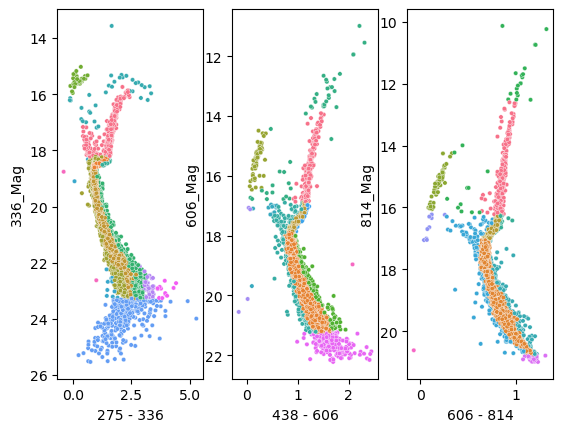

In [3]:
path_optical = 'C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC 6218/optical_data.txt'
path_arrival_optical = 'C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC6809_optical.csv'
creating_optical_csv(path_optical, path_arrival_optical, Mag_min = -50, Mag_max = 50, RMS_max = 1, Fit_max = 1.5, Sharp_min = -2, Sharp_max = 2, CM_min = 80,
                         bins_division = 20, min_count = 2, min_step = 2,
                         bluer_limit = 0.5, significantly_bluer_limit = 1.0, redder_limit = 0.5, significantly_redder_limit = 1.0)
